# Estimating TESS rotation periods with CNNs

## Introduction

The NASA TESS mission conducts an all-sky survey searching for exoplanets that transit their host stars. To do so, it collects time series photometry called "light curves" for millions of stars across the sky. These light curves have many science uses besides exoplanets, including stellar rotation. As a star rotates, cool magnetic spots come into and out of view, causing periodic wiggles in the brighness measurements through time. We can therefore use light curves from TESS to infer stellar rotation periods, which are useful for studying stellar magnetism, structure, and ages. 

However, systematics associated with the telescope's special Earth-Moon orbit make it difficult to measure long (> 13 day) rotation periods from TESS light curves using conventional frequency analysis techniques. Machine learning methods, and in particular Convolutional Neural Networks (CNN) have been shown to circumvent some of the effects of systematics and estimate rotation periods from TESS light curves and their frequency transforms.

In this tutorial we will use a CNN to estimate stellar rotation periods from frequency transforms of TESS light curves. For our training set, we will use the simulations from the MAST High Level Science Product [SMARTS](https://archive.stsci.edu/hlsp/smarts). SMARTS combines physically realistic simulations of rotational light curves with real noise and systematics from TESS. This combination allows CNNs to learn the difference between rotation signals and systematics and estimate stellar rotation periods.

## Goals
The goal of this notebook is to use [SMARTS](https://archive.stsci.edu/hlsp/smarts) data to train a CNN to regress TESS rotation periods. We will

0. [Configure the training run](#0.configure-training-run),
1. [Prepare the training data](#1.prepare-training-data),
2. [Build the CNN](#2.build-the-cnn),
3. [Define training, validation, and evaluation functions](#3.define-training-validation-and-evaluation-functions),
4. [Train the CNN](#4.train-the-cnn-on-smarts-data), and
5. [Test the CNN performance](#5.test-the-cnn-performance).

The training examples are 2-dimensional arrays of wavelet transforms of TESS light curves. The wavelet transform concentrates the periodicity of the light curve, making it easier for a CNN to regress the period. CNNs take advantage of the image-like nature of a wavelet transform in the same way that CNNs are useful for image recognition and computer vision.

## Runtime

On the [TIKE](https://timeseries.science.stsci.edu) "Large" instance, this notebook takes just under 3 minutes to run from start to finish. The bulk of this time is spent downloading the training data. Once you've done that once, you can comment out the cell, and the notebook will be faster.

This notebook, including the CNN training, is configured to run on a single CPU.

## Installs and Imports
This notebook uses the following packages:
- `glob` for generating lists of training files
- `copy` for saving training weights
- `numpy` for array operations
- `matplotlib` for plotting
- `astropy` for reading FITS files
- `torch` for tensor and CNN operations

You can install the requirements by running `%pip install -r requirements.txt`.

In [1]:
from glob import glob  # for generating lists of input files
from copy import deepcopy  # for saving CNN weights

import numpy as np  # array operations
from astropy.io import fits  # FITS file operations
import matplotlib.pyplot as plt  # for plotting

# For tensor and CNN operations
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## 0. Configure training run

Before we get started, we need to set some configuration parameters to know how much data to read in, and how many epochs to train for. Ideally, we want to run on the full training set (`max_n = 1_000_000`) for long enough that the loss plateaus (usually `num_epochs = 500`). But this for this simple demo, we will use a subset of training data and a shorter training time. We will train/validation/test using a 80%/10%/10% `split`, and we'll build a CNN with 3 convolution layers with filter depths increasing from 8, to 16, to 32 `filters`.

In [2]:
max_n = 10_000  # max 1_000_000
num_epochs = 20  # 100 is pretty good, typically ~300 to 500 to reach a plateau
split = [8, 1, 1]  # ratios for train/validation/test split
filters = [8, 16, 32]  # list of CNN layer filter depths

## 1. Prepare training data

The SMARTS training data are in the form of continuous Morlet wavelet transforms (CWTs) or wavelet power spectra (WPS). Rather than train on the light curve itself, the WPS provides a 2D representation of the frequency information present in the light curve. With frequency or period on the y-axis and time on the x-axis, the WPS illustrates which frequencies dominate the light curve at different times. Since it is effectively an image, we can take advantage of image recognition capabilities of CNNs.

For more information on CWTs, see
- [_A Practical Guide to Wavelet Analysis_, Torrence & Compo (1998)](https://ui.adsabs.harvard.edu/abs/1998BAMS...79...61T/abstract)
- [The `pycwt` Python package](https://github.com/regeirk/pycwt)

We will first download and extract the data, load it into a DataLoader, and then look at an example.

In [3]:
# Download and extract training data
# Comment this cell out if you've already downloaded and extracted the data once!
!curl -o hlsp_smarts_tess_ffi_all_tess_v1.0_cat.tar.gz https://archive.stsci.edu/hlsps/smarts/tess/hlsp_smarts_tess_ffi_all_tess_v1.0_cat.tar.gz
!tar -xvzf hlsp_smarts_tess_ffi_all_tess_v1.0_cat.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0 1873M    0 6304k    0     0  6799k      0  0:04:42 --:--:--  0:04:42 6800k

  1 1873M    1 20.7M    0     0  10.7M      0  0:02:54  0:00:01  0:02:53 10.7M

  2 1873M    2 39.5M    0     0  13.5M      0  0:02:18  0:00:02  0:02:16 13.5M

  3 1873M    3 60.0M    0     0  15.2M      0  0:02:02  0:00:03  0:01:59 15.2M

...

 90 1873M   90 1688M    0     0  33.8M      0  0:00:55  0:00:49  0:00:06 52.8M

 93 1873M   93 1757M    0     0  34.5M      0  0:00:54  0:00:50  0:00:04 55.2M

 97 1873M   97 1833M    0     0  35.3M      0  0:00:53  0:00:51  0:00:02 58.3M

100 1873M  100 1873M    0     0  35.7M      0  0:00:52  0:00:52 --:--:-- 61.3M


hlsp_smarts_tess_ffi_all_tess_v1.0_sim.fits


We will partition the data into three sets: a training, validation, and test set.
- The training set is used to fit the CNN parameters
- The validation set is held-out for use to determine when to stop training. The training loss will decrease indefinitely, but the validation loss will stop decreasing when the CNN begins to overfit, signalling that it's reached a local maximum in its ability to generalize to new data.
- The test set is used for the final performance evaluation.

We use Pytorch `Dataset` (subclassed here) and `DataLoader` (used below) to load the wavelet data. Pytorch `Dataset` and `DataLoader` can be accessed in batches, which makes training more efficient.

In [4]:
# Define Dataset and Dataloader classes
class WaveletDataset(Dataset):
    """
    WaveletDataset to read in the training data.

    Attributes
    ----------
    periods: array of rotation period corresponding to each wavelet transform.

    wavelets: array containing the stack of wavelet transforms.
    """

    def __init__(self, periods, wavelets, mode, random_seed=42, max_n=10000, split=(8, 1, 1), normalize=True):
        """
        Parameters
        ----------
        `periods` (numpy.ndarray): the array of rotation periods, or labels.

        `wavelets` (numpy.ndarray): the array of wavelet power spectra, or features.

        `mode` (str): must be one of "train", "validation", or "test". Loads different data
            depending on the specified mode.

        `random_seed` (int, optional): seed for random number generator for 
            reproducibility.

        `max_n` (int, optional): the number of training examples to use.

        `split` (list-like): the split fractions for train/validation/test partitions

        `normalize` (bool): whether to divide the periods and wavelets by their maximum values.
        """

        # create shuffled index and shuffle arrays
        np.random.seed(random_seed)
        idx = np.random.choice(np.arange(len(periods), dtype=int), size=max_n, replace=False)
        p = periods[idx]
        w = wavelets[idx]

        if normalize:
            pmax = periods.max().item()
            wmax = wavelets.max().item()
            p = (p/pmax).astype(np.float32)
            w = (w/wmax).astype(np.float32)
        else:
            pmax = np.nan
            wmax = np.nan
            p = p.astype(np.float32)
            w = w.astype(np.uint8)
        self.pmax = pmax
        self.wmax = wmax

        # determine how many examples to use for each partition
        n_train, n_val, _ = (max_n * np.array(split)/np.sum(split)).astype(int).cumsum()

        if mode == "train":
            p = p[:n_train]
            w = w[:n_train]
        elif mode == "validation":
            p = p[n_train:n_val]
            w = w[n_train:n_val]
        elif mode == "test":
            p = p[n_val:]
            w = w[n_val:]
        else:
            raise ValueError("`mode` must be one of 'train', 'validation', or 'test'.")

        # Assign periods and wavelets to class attributes
        self.wavelets = w
        self.periods = p

    def __len__(self):
        """Returns the number of training examples in the Dataset.
        """
        return len(self.periods)

    def __getitem__(self, idx):
        """
        The data accessor.

        Parameters
        ----------
        `idx` (list-like): the list of indices to be accessed

        Returns
        -------
        `X` (tensor): substack of wavelet transforms

        `label` (tensor): sub-array of rotation periods
        """
        if torch.is_tensor(idx):
            idx = idx.tolist()
        X = torch.tensor(self.wavelets[idx], dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.periods[idx, np.newaxis])
        return X, label

In [5]:
# Read SMARTS data into data loaders
filename = "hlsp_smarts_tess_ffi_all_tess_v1.0_sim.fits"
print(f"Reading data from {filename}...", end="")

with fits.open(filename, memmap=True) as f:
    p = f[1].data["Period"]
    w = f[2].data
    train_dataset = WaveletDataset(p, w, mode="train", max_n=max_n, split=split)
    valid_dataset = WaveletDataset(p, w, mode="validation", max_n=max_n, split=split)
    test_dataset = WaveletDataset(p, w, mode="test", max_n=max_n, split=split)

print("Done.")

print("Storing training data into DataLoaders...", end="")
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=50)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=50)
print("Done.")

Reading data from hlsp_smarts_tess_ffi_all_tess_v1.0_sim.fits...

Done.
Storing training data into DataLoaders...Done.


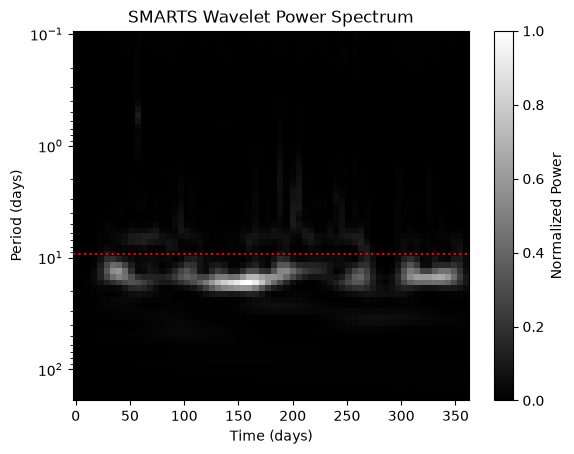

In [6]:
# Plot an example WPS
wl, p = train_dataset[8]

wldata = wl.squeeze().numpy()

plt.figure()
plt.pcolormesh(
    np.linspace(0, 360, len(wldata)),  # time baseline is about a year
    np.geomspace(0.1, 180, len(wldata)),  # period axis goes from 0.1 to 180
    wldata,
    shading="nearest",
    cmap="binary_r"
)
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Period (days)")
plt.gca().invert_yaxis()
plt.title("SMARTS Wavelet Power Spectrum")
plt.colorbar(label="Normalized Power")

# Plot the actual rotation period of the simulated star
plt.axhline(180*p.numpy().item(), color="r", linestyle=":");

This is an example of a WPS. For sinusoidal signals, there is a horizontal band of power at the dominant frequency. This example star has an equatorial rotation period of about 9 days, but the dominant frequency from the power spectrum is about 10.5 days. This is due to surface differential rotation, where spots emerge at higher latitudes that rotate more slowly than the equator.

This panel (without the axes or colorbar) is what the CNN will be trained on.

## 2. Build the CNN

We will build a CNN that takes 2D input (the WPS) and predicts two values: the stellar rotation period and its corresponding uncertainty. The CNN has the following aspects:
- Three 2D convolution layers for feature extraction
- ReLU activation
- 1D max pooling in the time axis, for dimensionality reduction without losing frequency resolution.
- Dropout to build redundancy and avoid overfitting
- Softplus output for regression

The CNN also has a configurable number of feature extractors (also called "kernels" or "filters"), which is set by the `c` parameter. It defaults to `[8, 16, 32]`, so that each successive convolution layer increases in depth by a factor of 2. You might also try `[16, 32, 64]` or `[32, 64, 128]` to see whether more feature extractors improve the performance.

In [7]:
class ConvNet(nn.Module):
    """
    A relatively simple 2D Convolutional Neural Network with a configurable
    number of trainable convolution kernels.
    
    Parameters
    ----------
    c (list of ints, [8, 16, 32]): List of convolutional kernel depths.
    
    k (int or list of ints, 3): Convolutional kernel widths. If an int is
        passed, it will be multiplied into a list of length `len(c)`.
    """
    def __init__(self, c=[8, 16, 32], k=3):
        if isinstance(k, int):
            k = [k]*len(c)
            
        n_nodes = (64 - (sum(k) - len(k))) * c[-1]

        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(  1,  c[0], k[0], 1)  # 62 x 20
        self.conv2 = nn.Conv2d(c[0], c[1], k[1], 1)  # 60 x 6 
        self.conv3 = nn.Conv2d(c[1], c[2], k[2], 1)  # 58 x 1
        self.fc1 = nn.Linear(n_nodes, 256)  # 58 x 32 = 1856
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 2)
        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout2d(0.1)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, (1, 3))
        x = self.dropout2(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, (1, 3))
        x = self.dropout2(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, (1, x.shape[-1]))
        x = self.dropout2(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout1(x)
        output = F.softplus(self.fc3(x))
        return output

Here we will also define our loss function. A typical loss function for regression is the mean squared error (MSE). However, MSE doesn't allow for the prediction of uncertainties. Alternative loss functions that allow the prediction of uncertainties include the Laplacian and Gaussian Negative Log-Likelihoods (NLL). Gaussian NLL is analogous to MSE, while Laplacian NLL is analogous to median absolute error, which is less biased by outliers and more accurately predicts values near the edges of the training distribution. For these reasons, we will use the Laplacian NLL, which has the form

$L = \frac{1}{2b} \exp(\frac{-|x - \mu|}{b})$,

where $\mu$ is the mean, and $b$ is related to the variance $\sigma^2$ by $\sigma^2 = 2 b^2$.

The negative log-likelihood is then

$-\log L = \frac{|x - \mu|}{b} + \ln(2b)$.

You may find that other loss functions work better for your use case. We recommend trying several.

In [8]:
def laplacian_nll(y_pred, y_true, k=1):
    """
    Compute Negative Log Likelihood for Laplacian Output Layer. This loss function
    lets the CNN predict a value with a related uncertainty.

    Args:
        y_pred: Nx2k matrix of parameters. Each row parametrizes
                k Laplacian distributions, each with (mean, std).
        y_true: Nxk matrix of (data) target values.
    """
    means = y_pred[:, :k]
    sigmas = y_pred[:, k:]

    # convert from sigma to b
    b = sigmas / np.sqrt(2) 

    # compute NLL
    nll = torch.abs(means - y_true)/b + torch.log(2*b)
    return nll

def gaussian_nll(y_pred, y_true, k=1):
    """
    Compute Negative Log Likelihood for Gaussian Output Layer. This loss function
    lets the CNN predict a value with a related uncertainty.

    Args:
        y_pred: Nx2k matrix of parameters. Each row parametrizes
                k Laplacian distributions, each with (mean, std).
        y_true: Nxk matrix of (data) target values.
    """
    means = y_pred[:, :k]
    sigmas = y_pred[:, k:] 

    # compute NLL
    nll = ((means - y_true)/sigmas)**2 + torch.log(2*np.pi*sigmas)
    return nll/2

# Set the chosen loss function here
loss_function = laplacian_nll

## 3. Define training, validation, and evaluation functions

We train the CNN using the Adam optimizer, which uses adaptive learning rates (LR) to train the network. To vary the LR, we use a plateau scheduler (`ReduceLROnPlateau`), which reduces the LR when the loss plateaus. This enables the CNN parameters to find local minima more easily, rather than take large steps over them.

Finally, we will also use an early stopping criterion. This means that if the validation loss plateaus or increases for a certain number of epochs, training stops early, and the best fit CNN values are saved.

In [9]:
def train(model, train_loader, valid_loader, num_epochs=100, early_stopping_patience=10, device=torch.device("cpu")):
    """Train the neural network for all desired epochs.
    """
    optimizer = optim.Adam(model.parameters(), lr=5e-5)
    # Set learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.7, patience=3)

    # Set up training loop
    train_p_loss = []
    val_p_loss = []
    min_loss = 100
    early_stopping_count = 0
    best_epoch = 0

    for epoch in range(1, num_epochs + 1):
        # Compute a single epoch of training
        p_loss = train_epoch(model, train_loader, optimizer, epoch, device=device)
        train_p_loss.append(p_loss)
        p_loss = evaluate(model, valid_loader)
        val_p_loss.append(p_loss)
        total_loss = p_loss
        scheduler.step(total_loss)  # step learning rate scheduler

        # if new fit is better than the previous best fit, update best fit weights
        if total_loss < min_loss:
            min_loss = total_loss
            early_stopping_count = 0
            best_epoch = epoch
            best_weights = deepcopy(model.state_dict())
        # otherwise, if loss is not getting better, count down to stopping criterion
        else:
            early_stopping_count += 1
            print(f"Early Stopping Count: {early_stopping_count}")
            if early_stopping_count == early_stopping_patience:
                print(f"Early Stopping. Best Epoch: {best_epoch} with loss {min_loss:.4f}.")
                with open("best_epoch.txt", "w") as f:
                    print(best_epoch, file=f)
                break    

    # save and return the best fit weights
    torch.save(best_weights, f"model.pt")
    return best_weights, train_p_loss, val_p_loss


def train_epoch(model, train_loader, optimizer, epoch, device=torch.device("cpu")):
    """Train the network for a single epoch.
    """
    model.train()  # Set the model to training mode
    period_losses = []
    # iterate over data batches
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device, dtype=torch.float), target.to(device, dtype=torch.float)
        optimizer.zero_grad()  # Clear the gradient
        output = model(data)  # Make predictions
        loss = loss_function(output, target).mean()
        loss.backward()  # Gradient computation        
        optimizer.step()  # Perform a single optimization step
        period_losses.append(loss.item())

        # print progress every few batches
        if (batch_idx*len(data)) % 500 == 0:
            print("Epoch: {:3d} [{:5d}/{:5d} ({:3.0f}%)] Training Loss: {:9.6f}".format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), period_losses[-1]))
            
    # return the mean loss value
    return np.mean(period_losses)


def evaluate(model, test_loader, verbose=True, device=torch.device("cpu"), return_predictions=False):
    """
    Evaluate network on validation or test data and compute loss.
    This is like "train" except the weights are not updated.
    """
    model.eval()  # Set the model to inference mode
    test_p_loss = 0
    targets = []
    preds = []
    with torch.no_grad():  # For the inference step, gradient is not computed
        for data, target in test_loader:
            data, target = data.to(device, dtype=torch.float), target.to(device, dtype=torch.float)
            output = model(data)
            targets.extend(target.cpu().numpy())
            preds.extend(output.cpu().numpy())
            test_p_loss += loss_function(output, target).sum()
            
    test_p_loss /= len(test_loader.dataset)

    if verbose:
        print(f"Test loss: {test_p_loss:.4f}")
    if return_predictions:
        return test_p_loss, np.squeeze(preds), np.squeeze(targets)
    return test_p_loss

## 4. Train the CNN on SMARTS data

In [10]:
# Initialize CNN
model = ConvNet(c=filters)

# Train CNN
weights, train_p_loss, val_p_loss = train(model, train_loader, valid_loader,
    early_stopping_patience=10, num_epochs=num_epochs)

Epoch:   1 [    0/ 8000 (  0%)] Training Loss:  0.569471


Epoch:   1 [  500/ 8000 (  6%)] Training Loss:  0.615291


Epoch:   1 [ 1000/ 8000 ( 12%)] Training Loss:  0.479290


Epoch:   1 [ 1500/ 8000 ( 19%)] Training Loss:  0.465898


Epoch:   1 [ 2000/ 8000 ( 25%)] Training Loss:  0.507753


...

Epoch:  20 [ 6000/ 8000 ( 75%)] Training Loss:  0.105130


Epoch:  20 [ 6500/ 8000 ( 81%)] Training Loss:  0.222100


Epoch:  20 [ 7000/ 8000 ( 88%)] Training Loss:  0.220846


Epoch:  20 [ 7500/ 8000 ( 94%)] Training Loss:  0.242182


Test loss: 0.1706


Now that the CNN is trained, we should take a look at the "learning curves," or the loss over time.

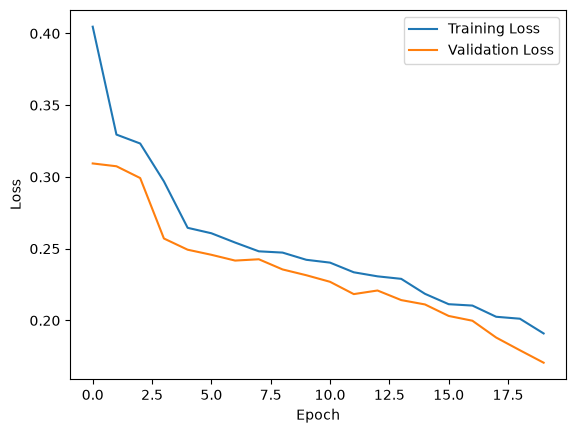

In [11]:
plt.figure()
plt.plot(train_p_loss, label="Training Loss")
plt.plot(val_p_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend();

For this exercise, we only trained on a small subset of the training data, and for a limited number of training epochs. This means that the CNN hasn't yet reached a plateau, and it's not fully trained. You will see better performance by training for more epochs (until the loss values plateau), which you can configure back in [Section 0](#0.configure-training-run) by changing `num_epochs`. You can also train on a larger piece of the training data by configuring `max_n` in the same cell. 

## 5. Test the CNN performance

Now we use the trained CNN to predict stellar rotation periods from a held-out test set, and compare the predictions to the true values. 

Since we're only training over a small fraction of the training set in this tutorial, we don't expect the predictions to match the true values. You will see better performance by training on a larger piece (or all) of the training set, or training for more epochs, by configuring `max_n` or `num_epochs` back in [Section 0](#0.configure-training-run).

In [12]:
# evaluate CNN to infer rotation periods
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=50)
test_loss, preds, trues = evaluate(model, test_loader, verbose=True, return_predictions=True)

Test loss: 0.1355


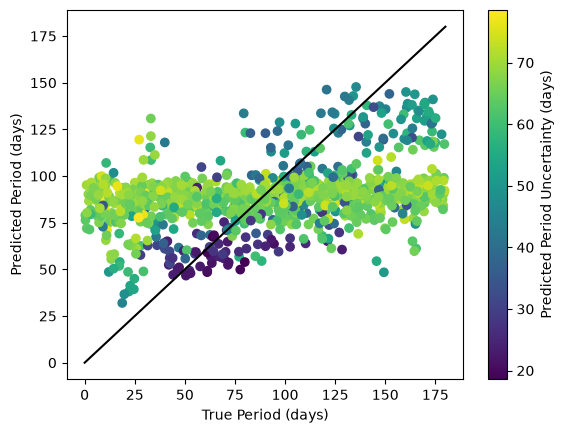

In [13]:
# compare the CNN predictions to the true values
%matplotlib inline

true_periods = trues*test_dataset.pmax
pred_periods = preds[:, 0]*test_dataset.pmax
pred_sigma = preds[:, 1]*test_dataset.pmax

plt.scatter(true_periods, pred_periods, c=pred_sigma)
plt.plot([0, 180], [0, 180], "k")
plt.xlabel("True Period (days)")
plt.ylabel("Predicted Period (days)")
plt.colorbar(label="Predicted Period Uncertainty (days)");

Most of the data are predicted to have the median period of 90 days, which is the best guess when the CNN doesn't know better. We also predicted the uncertainty in the period, so let's see what that looks like.

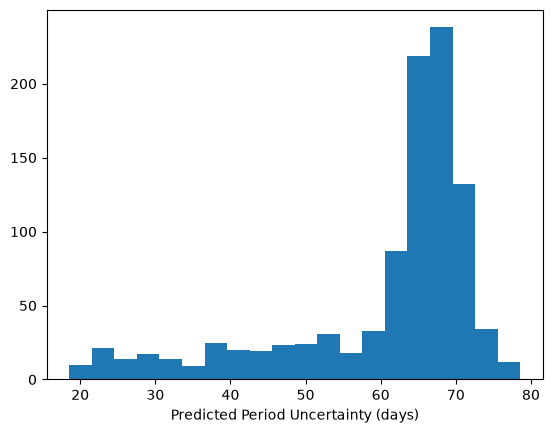

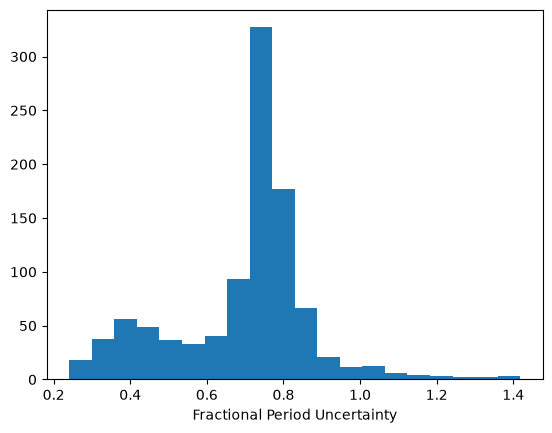

In [14]:
sigmas = preds[:, 1]*test_dataset.pmax
frac = sigmas/pred_periods

plt.figure()
plt.hist(sigmas, bins=20)
plt.xlabel("Predicted Period Uncertainty (days)")

plt.figure()
plt.hist(frac, bins=20)
plt.xlabel("Fractional Period Uncertainty");

We can start to see a dip forming at sigma/period ~ 0.5 in the second plot (this dip will become more pronounced for longer training runs), so let's use that to filter the results, weeding out "bad" predictions.

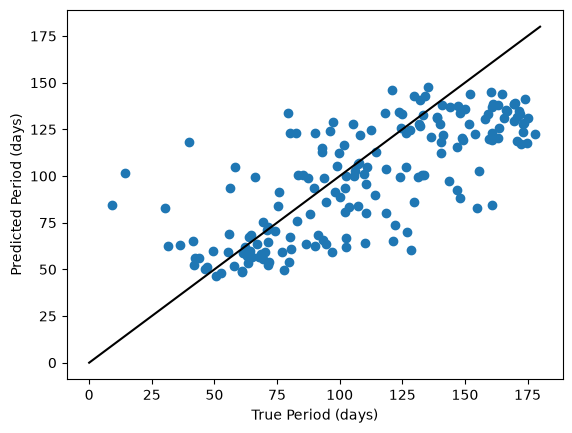

In [15]:
true_filtered = true_periods[frac < 0.5]
pred_filtered = pred_periods[frac < 0.5]
plt.scatter(true_filtered, pred_filtered)
plt.plot([0, 180], [0, 180], "k")
plt.xlabel("True Period (days)")
plt.ylabel("Predicted Period (days)");

With the "bad" predictions filtered out, the predictions look much better, even after only 20 epochs. Remember that the uncertainty is predicted from the quality of the data, so this kind of cut can be applied to predictions on real data as well. 

While our loss function can serve as a metric of accuracy, we might also be interested in more classical accuracy metrics to measure the performance of the CNN. As an example, let's take a look at the root-mean-squared (RMS) error.

In [16]:
def rms_error(true, pred):
    return np.sqrt(np.mean((true - pred)**2))

print(f"Unfiltered prediction count: {len(pred_periods)}\n"
      f"RMS error: {rms_error(true_periods, pred_periods):.2f} days\n\n"
      f"Filtered prediction count:   {len(pred_filtered)}\n"
      f"RMS error: {rms_error(true_filtered, pred_filtered):.2f} days.")

Unfiltered prediction count: 1000
RMS error: 47.11 days

Filtered prediction count:   179
RMS error: 29.72 days.


When the predictions are filtered, we retain only a fraction of the test data, but the accuracy improves significantly. Note that

- Filtering by predicted uncertainty improves the accuracy. This implies that the predicted uncertainty is a useful estimator of the true credibility of CNN predictions.
- While only a fraction of the test set is left after filtering, remember that we trained for only 20 epochs, and on a subset of the training data. Doing a full run will improve both the accuracy of predictions *and* the number of "good" predictions.

## Summary

CNNs are useful machine learning models that can leverage spatially correlated information in images and image-like data. CNNs trained on simulated light curve wavelet transforms make reasonable predictions of the rotation periods of TESS stars despite the complicated orbit-related systematics present in the light curves.

In this tutorial, we
1. downloaded and preprocessed training data from MAST,
2. built a CNN using `pytorch`,
3. defined training, validation, and evaluation functions,
4. trained the CNN, and
5. analyzed the CNN performance on held-out test data.

We explored various machine learning and astrophysics concepts, including
- stellar rotation with TESS light curves,
- continuous wavelet transforms, and
- specialized loss functions to predict values with uncertainty.

## Next Steps

Now that we've run the base case, try the following exercises:
- train on a larger fraction of the training data by increasing `max_n`,
- train for more epochs by increasing `num_epochs`,
- use different train/validation/test ratios by modifying `split`,
- use larger convolution filter depths by changing `filters`,
- use Gaussian NLL loss to train the CNN.

See how any of these choices might affect the CNN performance.

## References

- [_Recovery of TESS Stellar Rotation Periods Using Deep Learning_ (Claytor et al. 2022)](https://ui.adsabs.harvard.edu/abs/2022ApJ...927..219C/abstract)
- [_TESS Stellar Rotation up to 80 Days in the Southern Continuous Viewing Zone_ (Claytor et al. 2024)](https://ui.adsabs.harvard.edu/abs/2024ApJ...962...47C/abstract)
- [_A Practical Guide to Wavelet Analysis_ (Torrence & Compo 1998)](https://ui.adsabs.harvard.edu/abs/1998BAMS...79...61T/abstract)
- [Stellar Magnetism, Activity, and Rotation with Time Series (SMARTS)](https://archive.stsci.edu/hlsp/smarts)